# Unit 3 · Clustering & PCA

Course: **21CSC305P — Machine Learning**

## Aim
Group similar traffic hours and reduce vehicle count and temperature to one new feature.

## Assignment tasks
1. Implement K-means clustering, mixtures of Gaussians and Hierarchical clustering algorithm to categorize data.
2. Create a program to perform PCA.

## About this transport dataset
This is **real hourly road-sensor data** from westbound Interstate 94 between Minneapolis and Saint Paul, USA. A road sensor counts vehicles passing during each hour. We use **1,008 consecutive hours (42 days), from 13 April 2017 at 10:00 to 25 May 2017 at 09:00**, in the source's local timestamps.

**traffic_volume**: vehicles counted in that hour. **temperature_c**: air temperature in degrees Celsius. **date_time** identifies the hour and is not a numerical model feature.

The original dataset has 48,204 rows and includes weather and holidays from 2012–2018. Repeated weather descriptions can share a timestamp; their traffic counts were verified identical before keeping the first entry. The teaching CSV uses the first six weeks of the longest continuous hourly sequence. Temperature was converted from Kelvin by subtracting 273.15. No missing hours were filled and no measurements were invented.

Source: [UCI Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume). Citation: Hogue, J. (2019), DOI: 10.24432/C5X60B. License: CC BY 4.0. The complete original compressed CSV is included.

**What to tell faculty:** “I am studying traffic patterns using real vehicle counts from a highway sensor.” High vehicle count means a busy hour; without speed or capacity data it does not prove congestion. This small window is a classroom demonstration, not a validation across roads or seasons.

Run cells from top to bottom. Keep the `data` folder beside `notebooks`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from the project folder or from its notebooks folder.
try:
    df = pd.read_csv('data/traffic.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/traffic.csv')

df['date_time'] = pd.to_datetime(df['date_time'])
print('Number of traffic hours:', len(df))

Number of traffic hours: 1008


## Prepare the two features
Use measured vehicle count and air temperature for the same hour. Standardize because vehicles/hour and degrees Celsius have different scales. This unit explores all 1008 hours and does not evaluate a forecast. Do not include the timestamp or a traffic class label in clustering.

In [2]:
from sklearn.preprocessing import StandardScaler

data = df.copy()
features = data[['traffic_volume', 'temperature_c']]
scaled = StandardScaler().fit_transform(features)
display(features.head())

,traffic_volume,temperature_c
0,4576,8.26
1,5033,8.75
2,5138,9.00
3,5296,9.19
4,5400,10.26


## Experiment 1 · Three ways to cluster
K-means assigns points to the nearest center. Gaussian mixtures use probabilities. Hierarchical clustering repeatedly joins nearby groups. We choose two groups to inspect operating patterns. Inspect group means before naming them; they are not guaranteed to be light/heavy traffic classes.

,traffic_volume,temperature_c
cluster,,
0,1350.39,9.08
1,4897.74,13.50


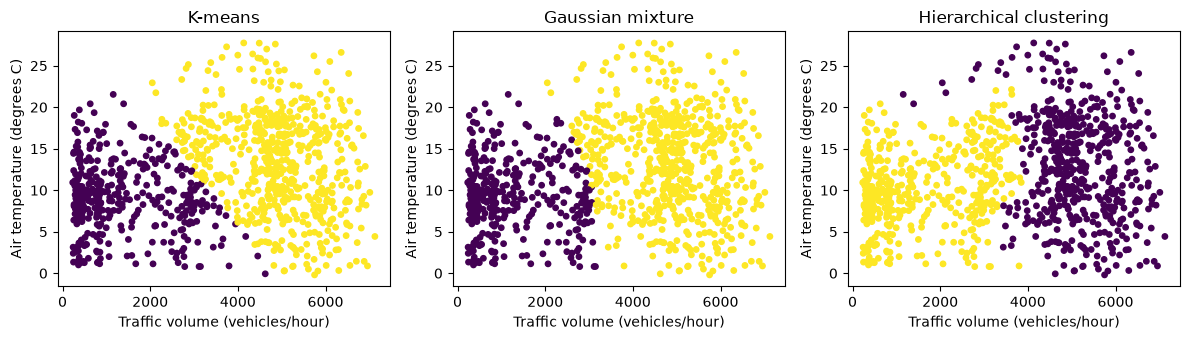

In [3]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled)
display(features.assign(cluster=kmeans_labels).groupby('cluster').mean().round(2))
mixture = GaussianMixture(n_components=2, random_state=42)
mixture_labels = mixture.fit_predict(scaled)
hierarchy = AgglomerativeClustering(n_clusters=2)
hierarchy_labels = hierarchy.fit_predict(scaled)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].scatter(data['traffic_volume'], data['temperature_c'], c=kmeans_labels, s=15)
axes[0].set_title('K-means')
axes[1].scatter(data['traffic_volume'], data['temperature_c'], c=mixture_labels, s=15)
axes[1].set_title('Gaussian mixture')
axes[2].scatter(data['traffic_volume'], data['temperature_c'], c=hierarchy_labels, s=15)
axes[2].set_title('Hierarchical clustering')
for ax in axes:
    ax.set_xlabel('Traffic volume (vehicles/hour)')
    ax.set_ylabel('Air temperature (degrees C)')
plt.tight_layout()
plt.show()

## Experiment 2 · PCA
PCA creates new features from the original ones. Here we compress two standardized features into one principal component and report how much variation it keeps.

Original shape: (1008, 2)
New shape: (1008, 1)
Variance kept: 60.31 %


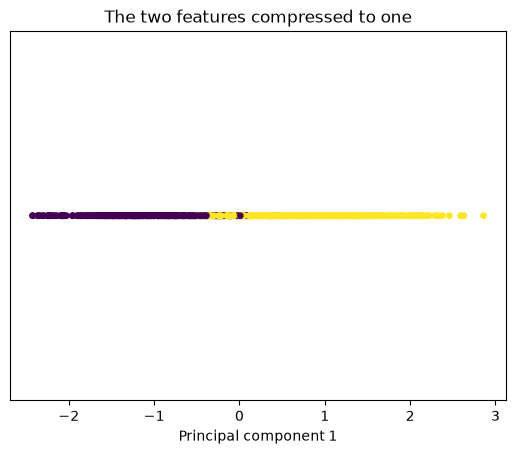

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
one_feature = pca.fit_transform(scaled)
print('Original shape:', scaled.shape)
print('New shape:', one_feature.shape)
print('Variance kept:', round(pca.explained_variance_ratio_[0] * 100, 2), '%')

plt.scatter(one_feature[:, 0], np.zeros(len(one_feature)), c=kmeans_labels, s=15)
plt.xlabel('Principal component 1')
plt.yticks([])
plt.title('The two features compressed to one')
plt.show()

## What to explain
Clustering does not need answer labels. Cluster 0 and cluster 1 are just names and can swap between methods. PCA reduces the number of features; it does not create a class label.

**Try:** Change `n_components=1` to `2` and compare the new shape.

**Viva:** Why scale vehicle count and temperature? What is `n_init`? How does GMM differ from K-means? What is Ward linkage? Is variance kept an accuracy score? How is clustering different from classification?